# Alzheimer MRI Classifier (CNN)

A Convolutional Neural Network built with PyTorch to classify Alzheimer's disease severity from brain MRI scans.

## Overview

| | |
|---|---|
| **Dataset** | Augmented Alzheimer MRI (Kaggle) — 4 classes |
| **Classes** | Mild Demented, Moderate Demented, Non Demented, Very Mild Demented |
| **Model** | CNN: 3 conv blocks + dense classifier with Dropout |
| **Loss** | CrossEntropyLoss |
| **Optimizer** | Adam (lr=0.001) |
| **Framework** | PyTorch |

## How to run
1. Set runtime to **GPU** : Runtime → Change runtime type → T4 GPU
2. Click **Runtime → Run all**

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alicelmre2705/deep-learning-projects/blob/main/alzheimer_mri_classifier.ipynb)

## 1. Setup

In [1]:
!pip install -q torch torchvision numpy matplotlib scikit-learn kagglehub

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/deep-learning-results'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Results will be saved to: {SAVE_DIR}')

Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/deep-learning-results


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import os

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2. Dataset Download

The dataset is downloaded automatically from Kaggle via `kagglehub`. It contains brain MRI scans classified into 4 categories of cognitive impairment.

In [4]:
import kagglehub

path = kagglehub.dataset_download("uraninjo/augmented-alzheimer-mri-dataset")
print("Dataset ready.")

# Auto-detect the actual directory structure
# kagglehub may nest files differently depending on version
def find_subdir(base, name):
    """Recursively find a subdirectory by name."""
    for root, dirs, files in os.walk(base):
        if name in dirs:
            return os.path.join(root, name)
    return None

TRAIN_DIR = find_subdir(path, "AugmentedAlzheimerDataset")
VAL_DIR = find_subdir(path, "OriginalDataset")

if TRAIN_DIR is None or VAL_DIR is None:
    # Fallback: show what we got so the user can adjust
    print("\n⚠️  Could not auto-detect dataset folders. Contents:")
    for root, dirs, files in os.walk(path):
        level = root.replace(path, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
        if level < 2:
            for d in dirs:
                print(f"{indent}  {d}/")
    raise FileNotFoundError("Set TRAIN_DIR and VAL_DIR manually based on the output above.")

print(f"Train: {len(train_dataset) if False else sum(len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in os.listdir(TRAIN_DIR))} images  |  Val: {sum(len(os.listdir(os.path.join(VAL_DIR, c))) for c in os.listdir(VAL_DIR))} images  |  {len(os.listdir(TRAIN_DIR))} classes")

100%|██████████| 380M/380M [00:10<00:00, 37.7MB/s]

Extracting files...


Dataset ready.
Train: 33984 images  |  Val: 6400 images  |  4 classes


In [5]:
# Hyperparameters
IMG_SIZE = 128
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 20
NUM_CLASSES = 4
CLASS_NAMES = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]

## 3. Data Loading

We apply data augmentation on the training set (random flips, rotation, color jitter) to improve generalization. Validation data is only resized and normalized.

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training samples:   33984
Validation samples: 6400
Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


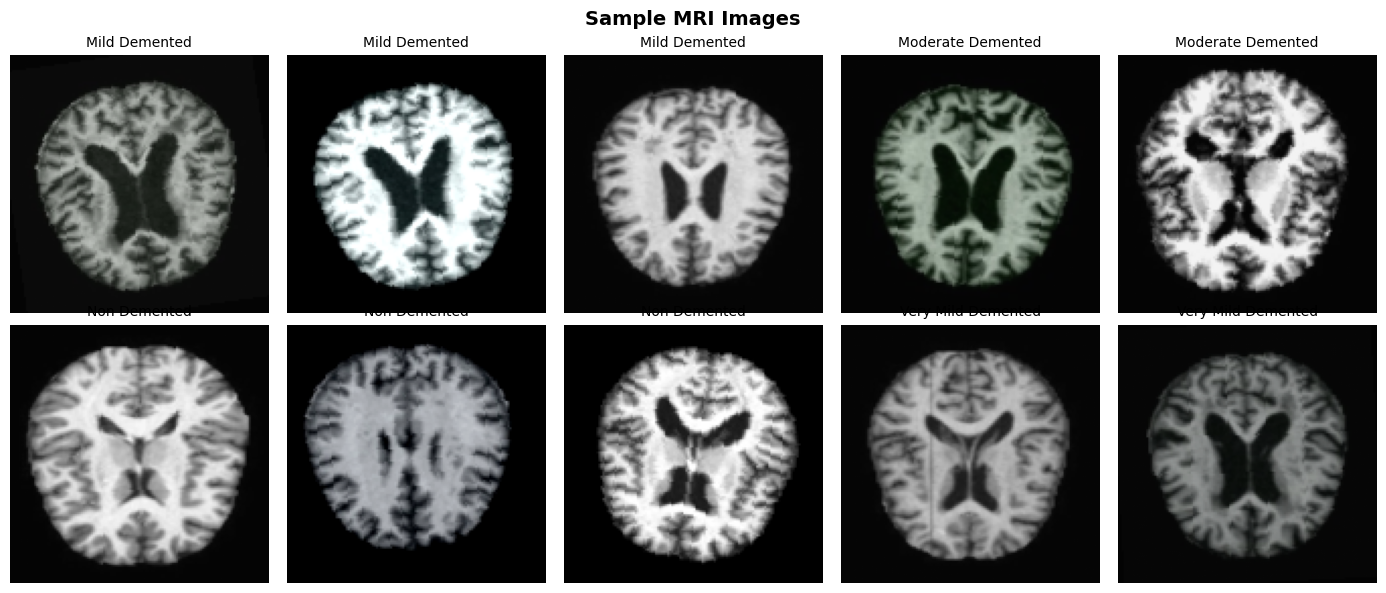

In [7]:
# Visualize samples
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i * (len(train_dataset) // 10)]
    img = image.permute(1, 2, 0) * 0.5 + 0.5  # denormalize
    ax.imshow(img.clamp(0, 1))
    ax.set_title(CLASS_NAMES[label], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample MRI Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Model Definition

3 convolutional blocks (Conv2d → ReLU → MaxPool) followed by a dense classifier with **Dropout(0.5)** to reduce overfitting.

We use **CrossEntropyLoss** instead of MSELoss — it's specifically designed for classification and converges faster.

In [8]:
model = nn.Sequential(
    # Block 1: 128x128 -> 63x63
    nn.Conv2d(3, 64, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Block 2: 63x63 -> 30x30
    nn.Conv2d(64, 128, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Block 3: 30x30 -> 14x14
    nn.Conv2d(128, 256, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Classifier
    nn.Flatten(),               # 256 * 14 * 14 = 50176
    nn.Dropout(0.5),
    nn.Linear(256 * 14 * 14, 256),
    nn.ReLU(),
    nn.Linear(256, NUM_CLASSES),
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Architecture : Conv(3→64) → Conv(64→128) → Conv(128→256) → Linear(50176→256) → Linear(256→4)")
print(f"Input size   : {IMG_SIZE}x{IMG_SIZE} px  |  Classes: {NUM_CLASSES}")
print(f"Total params : {total_params:,}  |  Device: {device}")

Architecture : Conv(3→64) → Conv(64→128) → Conv(128→256) → Linear(50176→256) → Linear(256→4)
Input size   : 128x128 px  |  Classes: 4
Total params : 13,217,156  |  Device: cuda


## 5. Training

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    val_acc = val_correct / val_total
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "alzheimer_cnn_best.pth")

    marker = " *" if val_acc == best_val_acc else ""
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  |  Loss: {epoch_loss:.4f}  |  Train: {epoch_acc:.4f}  |  Val: {val_acc:.4f}{marker}")

print(f"\nDone. Best val accuracy: {best_val_acc:.4f}")

Epoch  1/20  |  Loss: 1.0816  |  Train: 0.4984  |  Val: 0.5905 *
Epoch  2/20  |  Loss: 0.8039  |  Train: 0.6325  |  Val: 0.6269 *
Epoch  3/20  |  Loss: 0.7125  |  Train: 0.6707  |  Val: 0.6548 *
Epoch  4/20  |  Loss: 0.6455  |  Train: 0.7062  |  Val: 0.6767 *
Epoch  5/20  |  Loss: 0.5878  |  Train: 0.7359  |  Val: 0.7823 *
Epoch  6/20  |  Loss: 0.5492  |  Train: 0.7579  |  Val: 0.8036 *
Epoch  7/20  |  Loss: 0.5082  |  Train: 0.7780  |  Val: 0.8597 *
Epoch  8/20  |  Loss: 0.4798  |  Train: 0.7921  |  Val: 0.8352
Epoch  9/20  |  Loss: 0.4592  |  Train: 0.8046  |  Val: 0.8905 *
Epoch 10/20  |  Loss: 0.4295  |  Train: 0.8186  |  Val: 0.9227 *
Epoch 11/20  |  Loss: 0.4029  |  Train: 0.8307  |  Val: 0.9059
Epoch 12/20  |  Loss: 0.3909  |  Train: 0.8373  |  Val: 0.8959
Epoch 13/20  |  Loss: 0.3742  |  Train: 0.8456  |  Val: 0.9277 *
Epoch 14/20  |  Loss: 0.3557  |  Train: 0.8544  |  Val: 0.9581 *
Epoch 15/20  |  Loss: 0.3458  |  Train: 0.8565  |  Val: 0.9323
Epoch 16/20  |  Loss: 0.3301  |  

## 6. Training Curves

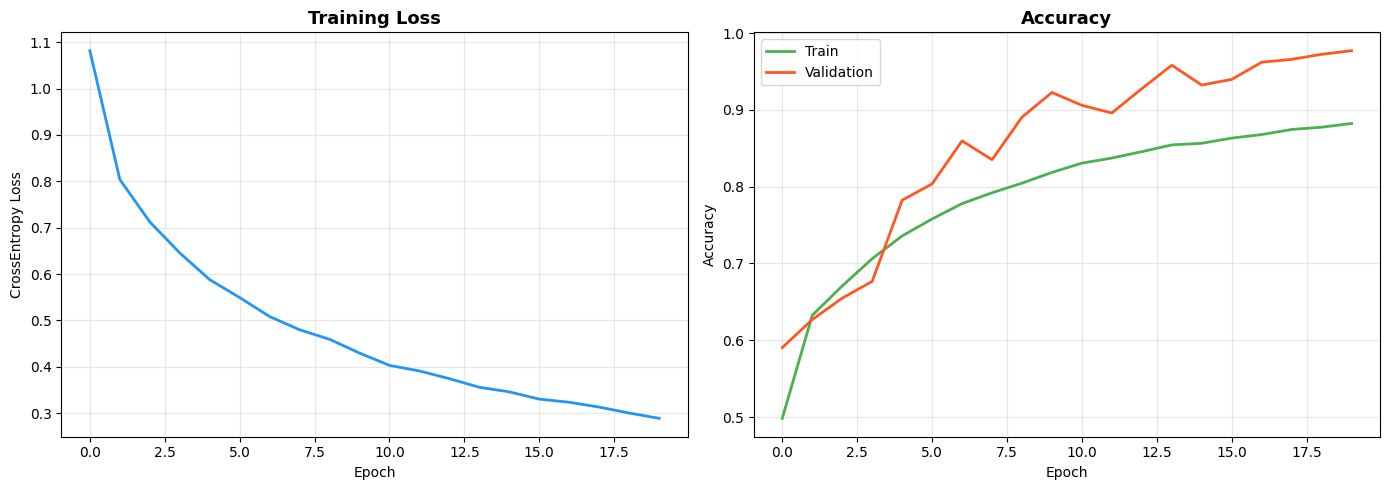

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, color="#2196F3", linewidth=2)
ax1.set_title("Training Loss", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("CrossEntropy Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(train_accuracies, label="Train", color="#4CAF50", linewidth=2)
ax2.plot(val_accuracies, label="Validation", color="#FF5722", linewidth=2)
ax2.set_title("Accuracy", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluation

In [11]:
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Classification Report:

                    precision    recall  f1-score   support

     Mild Demented       0.98      1.00      0.99       896
 Moderate Demented       1.00      1.00      1.00        64
      Non Demented       0.99      0.97      0.98      3200
Very Mild Demented       0.96      0.98      0.97      2240

          accuracy                           0.98      6400
         macro avg       0.98      0.99      0.98      6400
      weighted avg       0.98      0.98      0.98      6400



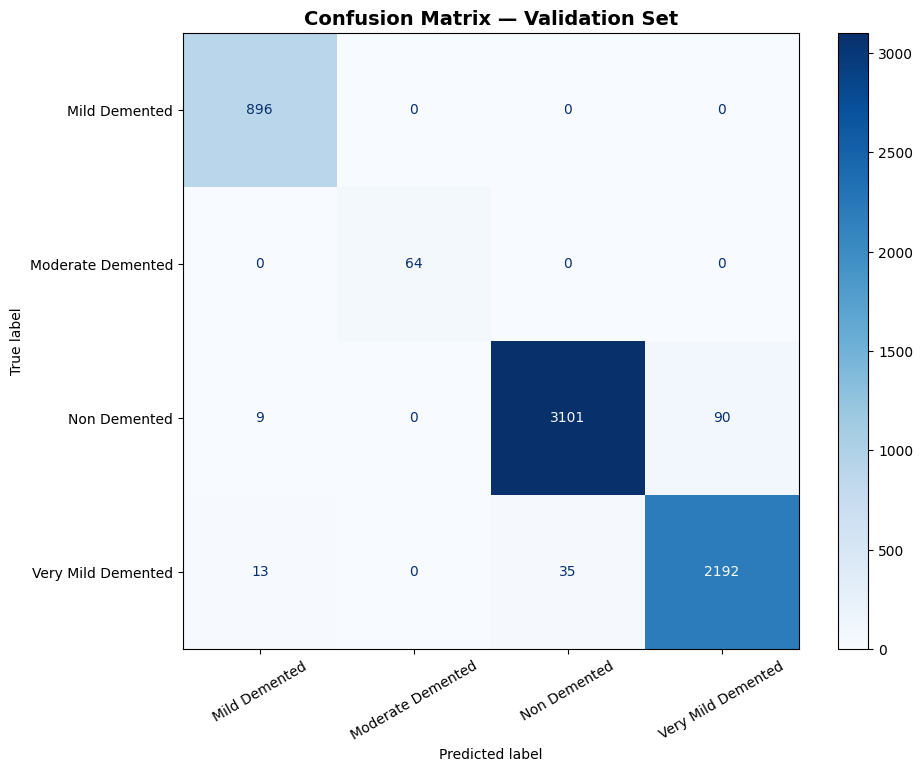

In [12]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=30)
ax.set_title("Confusion Matrix — Validation Set", fontsize=14, fontweight="bold")
plt.show()

## 8. Save Model

In [ ]:
import shutil, os, json, time
from IPython.display import Javascript, display

# Save model weights to Drive
torch.save(model.state_dict(), 'alzheimer_cnn_last.pth')
shutil.copy('alzheimer_cnn_last.pth', f'{SAVE_DIR}/alzheimer_cnn_last.pth')
shutil.copy('alzheimer_cnn_best.pth', f'{SAVE_DIR}/alzheimer_cnn_best.pth')
print(f'Saved  →  {SAVE_DIR}/alzheimer_cnn_last.pth')
print(f'Saved  →  {SAVE_DIR}/alzheimer_cnn_best.pth  (best val acc: {best_val_acc:.4f})')

# Save this notebook (with outputs) to Drive
from google.colab import _message

# Trigger a checkpoint first so all outputs are flushed
display(Javascript('IPython.notebook.save_checkpoint();'))
time.sleep(3)

try:
    nb_data = _message.blocking_request('get_ipynb', request={}, timeout_sec=120)
    dest = '/content/drive/MyDrive/Colab Notebooks/alzheimer_mri_classifier.ipynb'
    with open(dest, 'w') as f:
        json.dump(nb_data['ipynb'], f, indent=1, ensure_ascii=False)
    size_kb = os.path.getsize(dest) / 1024
    print(f'Notebook saved  →  Colab Notebooks/alzheimer_mri_classifier.ipynb  ({size_kb:.0f} KB)')
except Exception as e:
    print(f'Auto-save failed: {e}')
    print('→ File → Save a copy in Drive')

## 9. Conclusion

**Results**: The CNN classifier distinguishes the 4 Alzheimer severity levels from MRI scans. 'Non Demented' and 'Very Mild Demented' tend to be easier to classify than 'Mild' and 'Moderate'.

**Key takeaways**:
- CNNs learn spatial features automatically through convolutional filters — ideal for image classification.
- `CrossEntropyLoss` converges faster than MSELoss for classification.
- Dropout is essential to prevent overfitting on limited medical data.

**Possible improvements**:
- **Transfer learning** (ResNet, EfficientNet pretrained on ImageNet) for significantly better accuracy
- **Higher resolution** input (128x128 or 224x224) to capture finer MRI details
- **Class weighting** in the loss to handle class imbalance
- **Learning rate scheduling** (e.g., ReduceLROnPlateau)
- **More augmentation** (elastic deformations, Mixup)